# Generative AI for Data Augmentation

CyberEye Solutions, an emerging leader in cybersecurity for critical infrastructures, is facing a growing challenge in protecting power plants against advanced cyber threats. Currently, the power plant surveillance system uses image recognition technologies to identify and promptly respond to potentially dangerous situations. However, the ability to accurately and quickly recognize critical objects and behaviors in images is limited by the training datasets currently available, which do not fully represent the variability and complexity of real-world situations.

At present, existing models based on limited datasets fail to detect anomalies or potential threats in images with the required level of accuracy, compromising the company’s ability to respond to and mitigate emergency situations. Improving the ability to promptly identify critical objects and behaviors in images is essential to ensure operational continuity and the security of the critical infrastructures managed by CyberEye Solutions.

**Benefits of the Solution**

**1. Improved Security of Critical Infrastructures:**

Expanding the dataset using advanced Data Augmentation techniques will improve the accuracy of the image recognition system. A more precise and reliable model will be able to detect suspicious behaviors or potential threats in power plant images more quickly and accurately, thereby enhancing the security of critical infrastructures and reducing the risk of incidents or sabotage.

**2. Operational Efficiency and Reduced Response Time:**

By automating the process of generating new data through the creation of varied images and texts, CyberEye Solutions will optimize operational efficiency. This will allow the company to focus human resources on threat analysis and mitigation activities, reducing response times to critical events and improving emergency management capabilities.

**3. Technological Innovation in the Security Sector:**

By leveraging advanced deep learning and data generation techniques, CyberEye Solutions will foster innovation in the field of cybersecurity for critical infrastructures. The implementation of more sophisticated image recognition models will not only enhance the security of power plants, but also demonstrate the company’s commitment to adopting cutting-edge technologies to address emerging challenges in the cybersecurity sector.

**Project Details**

- **Dataset Acquisition:**

Use the OxfordIIITPet dataset from PyTorch as the foundation for the project aimed at improving the image recognition system for critical infrastructures.

- **Image Captioning and Data Generation:**

Apply image captioning to create initial descriptions of the images. Subsequently, use a text generation model to produce variations or analogous descriptions. Finally, employ an image generation model to create new images from the original captions or generated texts, thereby enriching the dataset with synthetic data.

**Model Training:**

Train an image recognition model using the expanded dataset, evaluating the quality of the generated data and comparing model performance on the reduced dataset versus the augmented dataset.

**Performance Evaluation:**

Measure accuracy, precision, recall, and other performance metrics to compare the model trained on both datasets. Discuss performance differences and the effectiveness of Data Augmentation techniques in improving model accuracy in real-world critical infrastructure security contexts.

**Conclusions**

CyberEye Solutions is committed to strengthening the security of critical infrastructures through the implementation of advanced image recognition solutions. By adopting innovative approaches and cutting-edge technologies, the company aims not only to improve the effectiveness of its cybersecurity systems, but also to set new industry standards for protecting critical infrastructures against increasingly sophisticated cyber threats.

**Delivery Method**

Public link to a Google Colab notebook

# Environment Setup & Dataset Preparation

This section initializes the Colab environment and prepares the dataset
for the generative data augmentation pipeline.

The steps include:
1. Cloning the project repository
2. Configuring logging verbosity
3. Installing dependencies
4. Importing project modules
5. Ensuring reproducibility
6. Loading and preparing the dataset
7. Creating a stratified reduced training subset

This setup ensures controlled experimentation, reproducibility,
and a clean execution environment.

In [1]:
# clone project repo into Colab env

import os

PROJECT_ROOT = "/content/Project_Generative_AI_for_Data_Augmentation"

# Avoid re-cloning if the directory already exists
if not os.path.exists(PROJECT_ROOT):
    !git clone -b dev https://github.com/Jorj91/Project_Generative_AI_for_Data_Augmentation.git {PROJECT_ROOT}

%cd {PROJECT_ROOT}

Cloning into '/content/Project_Generative_AI_for_Data_Augmentation'...
remote: Enumerating objects: 856, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 856 (delta 133), reused 64 (delta 58), pack-reused 663 (from 2)
Receiving objects: 100% (856/856), 33.62 MiB | 14.17 MiB/s, done.
Resolving deltas: 100% (461/461), done.
/content/Project_Generative_AI_for_Data_Augmentation


In [2]:
# CONTROLLED VERBOSITY for cleaner output

# Disable HF download progress bars BEFORE importing anything HF-related

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

In [3]:
# Install dependencies listed in requirements.txt
INSTALL_DEPS = True

if INSTALL_DEPS:
    !pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.5 MB/s eta 0:00:00


In [4]:
# import project modules
import sys
sys.path.append(os.path.join(PROJECT_ROOT, "src")) # add project "src" directory to python path

import importlib

# Import captioning module (image-to-text generation stage)
import captioning
importlib.reload(captioning)
from captioning import run_captioning

In [5]:
# import libraries & logging configuration
import torch
import logging
from torchvision.datasets import OxfordIIITPet
import numpy as np
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import random
from transformers.utils import logging as transformers_logging
from huggingface_hub.utils import logging as hf_logging

# Silence transformers & Hugging Face logs (keep only errors)
transformers_logging.set_verbosity_error()
hf_logging.set_verbosity_error()

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

In [6]:
# Reproducibility: fix random seed to ensure detrministic behaviour across runs
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [7]:
# GPU Memory clean up to free up GPU memory between large model executions
import gc

def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

In [8]:
PROJECT_ROOT # it must be /content/Project_Generative_AI_for_Data_Augmentation

'/content/Project_Generative_AI_for_Data_Augmentation'

In [9]:
# execution control flags

# ⚠️ WARNING:
# The following stages require substantial GPU memory. Recommended: A100 (40GB) or similar high-memory GPU.
# If running on limited hardware, consider setting FLAGS to False

RUN_CAPTIONING = True
RUN_TEXT_VARIATION = True
RUN_IMAGE_GENERATION = True
RUN_TRAINING = True

The Oxford-IIIT Pet dataset is used as the base dataset.
It contains 37 pet breeds with high-resolution images.
We use:
- trainval split for training
- test split for final evaluation

In [10]:
# dataset loading

dataset_train = OxfordIIITPet(
    root=os.path.join(PROJECT_ROOT, "data", "raw"),
    split="trainval",
    download=True
)

dataset_test = OxfordIIITPet(
    root=os.path.join(PROJECT_ROOT, "data", "raw"),
    split="test",
    download=True
)

print("Train size:", len(dataset_train))
print("Test size:", len(dataset_test))

100%|██████████| 792M/792M [00:44<00:00, 17.7MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.18MB/s]


Train size: 3680
Test size: 3669


Next, we create a stratified training subset. We select 30% of training data both for simulating a limited-data scenario and for computational reasons.
Stratified sampling ensures that class distribution is preserved, to prevent class imbalance from biasing the experiment.

This subset will be used for all following tasks of the project:
- Caption generation
- Text variation
- Synthetic image generation
- Augmented training

In [11]:
# extract labels for stratfication
labels = dataset_train._labels
indices = np.arange(len(dataset_train))

# perform stratified split
train_small_idx, _ = train_test_split(
    indices,
    train_size=0.30,
    stratify=labels,
    random_state=42
)

# Save indices for reproducibility and experiment tracking
SPLIT_DIR = os.path.join(PROJECT_ROOT, "data", "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)

np.save(os.path.join(SPLIT_DIR, "train_small_indices.npy"), train_small_idx)

In [12]:
train_small_idx

array([3037, 2635,  498, ...,  267, 2080, 1377])

In [13]:
# create subset dataset from training set using selected indices
dataset_train_small = Subset(dataset_train, train_small_idx)

# Image Caption Generation

In this stage, we generate descriptive captions for each image in the reduced training subset.

We use the BLIP-2 model (`Salesforce/blip2-opt-2.7b`) to produce structured,
controlled captions describing:

- The animal’s posture
- Its visual appearance
- Surrounding context

These captions serve as the semantic foundation for the subsequent
text variation and synthetic image generation stages.

In [ ]:
# caption output path

#This file will store the generated captions for the reduced training subset (30% stratified sample).
#Each image index maps to:
#- class_name
#- generated captions (2 per image)

CAPTION_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "captions",
    "captions_train_small.json"
)

In [ ]:
# Caption Generation using BLIP-2
# Estimated runtime: ~15 minutes on A100 GPU (on 30% subset) in colab
# We use BLIP-2 (2.7B parameters) for image-to-text generation.

if RUN_CAPTIONING:
  # select device automatically
  device = "cuda" if torch.cuda.is_available() else "cpu"

  # Load processor (handles image + text tokenization)
  processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

  # Load BLIP-2 model
  model = Blip2ForConditionalGeneration.from_pretrained(
      "Salesforce/blip2-opt-2.7b",
      torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32 # to reduce GPU memory usage
  )

  model.to(device)
  model.eval() # Inference mode

  # Run caption generation on reduced dataset
  captions_dict = run_captioning(
      dataset_train_small=dataset_train_small, # FOR ALL
      # dataset_train_small=dataset_train_small_10, # FOR 10
      model=model,
      processor=processor,
      device=device,
      output_path=CAPTION_PATH,
      preview_samples=10
  )

  # cleanup to free GPU memory
  del model
  del processor
  clear_gpu()
  !nvidia-smi

In [ ]:
# check date time of last change of given file
!stat "$CAPTION_PATH"

In [ ]:
# import nbformat
# nb = nbformat.read("main.ipynb", as_version=4)
# print("Stored outputs:", sum(len(c.get("outputs", [])) for c in nb.cells))

# Text variation

## FLAN-T5-Large Model



In this stage, we attempt to generate semantically faithful but lexically diverse caption variations using a LLM.

Model used: FLAN-T5-Large (770M parameters)

Objective:
- Generate 3 alternative phrasings per caption
- Preserve semantic meaning
- Increase lexical diversity
- Avoid hallucinations

In [ ]:
# Import FLAN-T5-Large text variation module

import importlib
import text_variation_flan_large
importlib.reload(text_variation_flan_large)
from text_variation_flan_large import run_text_variation as run_flan_large

In [ ]:
MAX_ITEMS = None # None = process fulldataset

In [ ]:
#input captions (generated from BLIP-2 stage)
CAPTION_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "captions",
    "captions_train_small.json"
)
#output file for FLAN-T5-Large variations
OUTPUT_PATH_FLAN_L = os.path.join(
    PROJECT_ROOT,
    "data",
    "captions",
    "captions_train_small_flan_large.json"
)

In [ ]:
# Run Text Variation (FLAN-T5-Large)
# Estimated runtime: ~45 minutes on A100 GPU (full subset)
# Sampling is enabled to encourage diversity.
flan_results = run_flan_large(
    caption_file=CAPTION_PATH,
    output_file=OUTPUT_PATH_FLAN_L,
    max_items=None
)

In [ ]:
# display first 10 caption samples generated by FLAN-T5-Large
all_entries = [
    (img, entry)
    for img, entries in flan_results.items()
    for entry in entries
]

for i, (img, entry) in enumerate(all_entries[:10], 1):
    print(f"\nSample {i}")
    print("Image:", img)
    print("Original:", entry["Original"])

    for j, v in enumerate(entry["Generated"], 1):
        print(f"  {j}. {v}")

    print("-" * 60)

In [ ]:
# Clean GPU memory
clear_gpu()
# !nvidia-smi

In [ ]:
# check date time of last change of given file
!stat "$OUTPUT_PATH_FLAN_L"

In [ ]:
# Optional: download results for inspection
from google.colab import files
files.download(OUTPUT_PATH_FLAN_L)

FLAN-T5-Large was evaluated as a candidate model for caption rewriting.

However, qualitative analysis showed several consistent issues:

- **poor semantic preservation:** generated output often drifted away from original meaning

- **hallucinations:** frequent introduction of unrelated object, people, or scenes

Due to these limitations, FLAN-T5-Large was deemed unsuitable for controlled data augmentation.

## FLAN-T5-XL Model

In this stage, we evaluate a larger instruction-tuned model:
FLAN-T5-XL (~3B parameters).

Motivation:
- Increase semantic faithfulness
- Reduce hallucinations observed in FLAN-T5-Large
- Evaluate whether larger model capacity improves paraphrasing quality

Unlike the previous model (which used sampling),
FLAN-T5-XL uses beam search for more deterministic and stable outputs.


In [ ]:
# FLAN-T5-XL Text Variation
# Estimated runtime: ~24 minutes on A100 GPU (full subset)
# Compared to FLAN-T5-Large:
# - Larger model (~3B parameters)
# - Uses beam search instead of sampling
# - Prioritizes semantic stability over lexical diversity


import importlib
import text_variation_flan_xl
from text_variation_flan_xl import run_text_variation as run_flan_xl
importlib.reload(text_variation_flan_xl)

OUTPUT_PATH_FLAN_XL = os.path.join(
    PROJECT_ROOT,
    "data",
    "captions",
    "captions_train_small_flan_xl.json"
)

flan_xl_results = run_flan_xl(
    caption_file=CAPTION_PATH,
    output_file=OUTPUT_PATH_FLAN_XL,
    max_items=None  # None = full dataset
)

In [ ]:
# Display first 10 caption samples generated by FLAN-T5-XL
all_entries = [
    (img, entry)
    for img, entries in flan_xl_results.items()
    for entry in entries
]

for i, (img, entry) in enumerate(all_entries[:10], 1):
    print(f"\nSample {i}")
    print("Image:", img)
    print("Original:", entry["Original"])

    for j, v in enumerate(entry["Generated"], 1):
        print(f"  {j}. {v}")

    print("-" * 60)

In [ ]:
# check date time of last change of given file
!stat "$OUTPUT_PATH_FLAN_XL"

In [ ]:
#clean GPU memory
clear_gpu()
# !nvidia-smi

In [ ]:
# Optional: download results for inspection
from google.colab import files
files.download(OUTPUT_PATH_FLAN_XL)

FLAN-T5-XL produced grammatically correct and semantically faithful rewrites.

However, the generated variations showed very low lexical diversity, often resulting in near-duplicate sentences with only minor wording or punctuation changes.

Since the goal of this stage is meaningful data augmentation, higher variation diversity was required.

## Mistral 7B Instruct Model

In this stage, we evaluate Mistral-7B-Instruct as a stronger generative model for caption rewriting.

Motivation:
- Reduce semantic drift observed in FLAN-T5-Large
- Improve lexical diversity beyond FLAN-T5-XL
- Achieve a better balance between diversity and faithfulness

Key characteristics:
- 7B parameter instruction-tuned causal LLM
- 4-bit quantization for memory efficiency
- Instruction-based prompt formatting
- Controlled sampling for natural paraphrasing

Based on qualitative evaluation, Mistral provided the best trade-off between semantic consistency and meaningful variation.

In [ ]:
# Mistral-7B-Instruct Text Variation
# Estimated runtime: ~1h30m on A100 GPU on colab (full subset).

import importlib
import text_variation_mistral
importlib.reload(text_variation_mistral)
from text_variation_mistral import run_text_variation as run_mistral

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
CAPTIONS_DIR = os.path.join(DATA_DIR, "captions")
TEXT_VARIATIONS_DIR = os.path.join(DATA_DIR, "text_variations")

os.makedirs(TEXT_VARIATIONS_DIR, exist_ok=True)

CAPTION_FILE = os.path.join(
    CAPTIONS_DIR,
    "captions_train_small.json"
)

TEXT_VARIATION_FILE = os.path.join(
    TEXT_VARIATIONS_DIR,
    "text_variations_train_small.json"
)

if RUN_TEXT_VARIATION:

    mistral_results = run_mistral(
        caption_file = CAPTION_FILE,
        output_file= TEXT_VARIATION_FILE,
        max_items=None # None = full dataset
    )

In [ ]:
# Display first 10 samples generated by Mistral-7B-Instruct

all_entries = list(mistral_results.items())

for i, (img, data) in enumerate(all_entries[:10], 1):
    print(f"\nSample {i}")
    print("Image:", img)
    print("Class:", data["class_name"])

    print("\nOriginal Captions:")
    for cap in data["original_captions"]:
        print("  -", cap)

    print("\nGenerated Variations:")
    for gen in data["generated_captions"]:
        print("  -", gen)

    print("-" * 60)

In [ ]:
#cjeck file creation
!stat $TEXT_VARIATION_FILE

In [ ]:
#clean GPU memory
clear_gpu()
# !nvidia-smi

In [ ]:
#optional: download results for inspection
from google.colab import files
files.download(TEXT_VARIATION_FILE)

Qualitative inspection of the generated captions shows that Mistral:

- Preserves the core semantic content of the original captions (breed identity, action, and scene context remain consistent).

- Produces structurally diverse paraphrases rather than near-duplicate rewordings

- Introduces natural lexical variation (e.g., “gazes at the camera”, “directs its attention towards the camera lens”)

- Maintains grammatical correctness and fluent sentence structure.

Based on this qualitative evaluation, Mistral-7B-Instruct was selected as the production model for caption variation.

# Caption Selection and Image Generation

After generating multiple text variations per image, we perform a filtering step
to select the most suitable captions for image synthesis.

Selection Criteria:
- High semantic similarity to original captions
- Low similarity to other generated captions (diversity)

Method:
- Sentence embedings using all-MiniLM-L6-v2
- Cosine similarity scoring
- Weighted ranking function:
  
  Final Score = 0.7 × similarity_to_original − 0.3 × similarity_to_generated

The top-2 captions per image are selected.
These selected captions are then used to generate synthetic images with Stable Diffusion v1.5.

## Caption Selection

In [20]:
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
CAPTIONS_DIR = os.path.join(DATA_DIR, "captions")
TEXT_VARIATIONS_DIR = os.path.join(DATA_DIR, "text_variations")

TEXT_VARIATION_FILE = os.path.join(
    TEXT_VARIATIONS_DIR,
    "text_variations_train_small.json"
)

In [18]:
from src.image_generation import (CaptionSelector, SyntheticImageGenerator)
import json

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [21]:
#load Mistral generated text variations
with open(TEXT_VARIATION_FILE, "r") as f:
    text_variations = json.load(f)

In [22]:
# estimated runtime: 1 min
selector = CaptionSelector()

selected_data = {}

for idx, data in text_variations.items():

    class_name = data["class_name"]
    original_captions = data["original_captions"]
    generated_captions = data["generated_captions"]
    # Select top-2 captions using weighted scoring
    selected_generated = selector.select_top_captions(
        original_captions,
        generated_captions,
        top_k=2
    )

    selected_data[idx] = {
    "class_name": class_name,
    "original_captions": original_captions,
    "selected_generated_captions": selected_generated
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# return first 10 samples of selected data
selected_data_10 = dict(list(selected_data.items())[:10])
selected_data_10

In [ ]:
# final save
output_file = os.path.join(DATA_DIR, "synthetic/selected_captions.json")

with open(output_file, "w") as f:
    json.dump(selected_data, f, indent=4)

## Image Generation with Stable Diffusion 1.5

In this stage, selected captions are converted into synthetic images using Stable Diffusion v1.5.

Key characteristics:
- Text-to-image generation
- Controlled random seed for reproducibility
- Batch processing
- Checkpoint saving to prevent data loss
- GPU memory optimization

The generated images are stored along with metadata for later training and evaluation.

In [23]:
# Verify CUDA availability before running heavy image generation t ensure that stable diffusion runs on GPU when available
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

CUDA available: True
Device count: 1


In [24]:
#Synthetic Image Generation using Stable Diffusion
# Estimated runtime: ~1h45m on A100 GPU (full subset) in colab

# For each selected caption:
#-build a structured prompt
#-generate high-resolution image (512x512)
#-save image to disk
#-store generation metadata
#
#Checkpoints are saved after each batch to prevent data loss in case of runtime interuption.
if RUN_IMAGE_GENERATION:
        generator = SyntheticImageGenerator()

        metadata = generator.generate_images(
                selected_data = selected_data,
                output_dir = os.path.join(DATA_DIR, "synthetic/images"),
                checkpoint_file = os.path.join(DATA_DIR, "synthetic/generation_checkpoint.json"),
                final_metadata_file = os.path.join(DATA_DIR, "synthetic/generation_metadata_final.json"),
                batch_size=4
        )
        # GPU memory cleanup
        del generator
        clear_gpu()
        # !nvidia-smi

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2186: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2213: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(
  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  1%|          | 1/195 [00:04<14:24,  4.46s/it]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

 99%|█████████▉| 194/195 [10:14<00:03,  3.24s/it]

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 195/195 [10:17<00:00,  3.17s/it]


GPU memory cleared.


In [25]:
# return first 10 samples of metadata
metadata_10 = dict(list(metadata.items())[:10])
metadata_10

{'3037': [{'image_path': '/content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/images/3037_0.png',
   'class_name': 'Pomeranian',
   'prompt': 'A high-resolution realistic photograph of a Pomeranian, my pomeranian dog is resting on the bed.',
   'source': 'synthetic'},
  {'image_path': '/content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/images/3037_1.png',
   'class_name': 'Pomeranian',
   'prompt': 'A high-resolution realistic photograph of a Pomeranian, the pomeranian breed of dog is occupying the bed where i am sitting.',
   'source': 'synthetic'}],
 '2635': [{'image_path': '/content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/images/2635_0.png',
   'class_name': 'Havanese',
   'prompt': 'A high-resolution realistic photograph of a Havanese, a havanese dog is positioned on a tennis court.',
   'source': 'synthetic'},
  {'image_path': '/content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/images/2635_1.png',
   'class_name'

In [26]:
checkpoint_file = os.path.join(DATA_DIR, "synthetic/generation_checkpoint.json")
final_metadata_file = os.path.join(DATA_DIR, "synthetic/generation_metadata_final.json")

!stat $checkpoint_file
!stat $final_metadata_file

  File: /content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/generation_checkpoint.json
  Size: 138006    	Blocks: 272        IO Block: 4096   regular file
Device: 38h/56d	Inode: 2263099     Links: 1
Access: (0644/-rw-r--r--)  Uid: (    0/    root)   Gid: (    0/    root)
Access: 2026-03-03 12:20:32.265149226 +0000
Modify: 2026-03-03 12:30:45.295184814 +0000
Change: 2026-03-03 12:30:45.295184814 +0000
 Birth: 2026-03-03 12:20:32.265149226 +0000
  File: /content/Project_Generative_AI_for_Data_Augmentation/data/synthetic/generation_metadata_final.json
  Size: 138006    	Blocks: 272        IO Block: 4096   regular file
Device: 38h/56d	Inode: 2263483     Links: 1
Access: (0644/-rw-r--r--)  Uid: (    0/    root)   Gid: (    0/    root)
Access: 2026-03-03 12:30:45.298185045 +0000
Modify: 2026-03-03 12:30:45.301185275 +0000
Change: 2026-03-03 12:30:45.301185275 +0000
 Birth: 2026-03-03 12:30:45.298185045 +0000


In [27]:
# Optional: download results for inspection
from google.colab import files
files.download(checkpoint_file)
files.download(final_metadata_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

To visually demonstrate the results in the repository,
a random subset of 20 generated images is copied to a separate folder.

In [28]:
# copy 20 random images generated to showcase in git
import shutil
import random

SHOWCASE_DIR = os.path.join(DATA_DIR, "showcase_images")
os.makedirs(SHOWCASE_DIR, exist_ok = True)

IMAGES_DIR = os.path.join(DATA_DIR, "synthetic/images")

# get all generated PNG images sorted
generated_images = sorted([
    os.path.join(IMAGES_DIR, f)
    for f in os.listdir(IMAGES_DIR)
    if f.endswith("png")
])

# randomly sample up to 20 images
sample_images = random.sample(
    generated_images,
    min(20, len(generated_images))
)

# clear showcase folder first
for f in os.listdir(SHOWCASE_DIR):
    os.remove(os.path.join(SHOWCASE_DIR, f))

# copy into showcase dir
for img_path in sample_images:
  shutil.copy(img_path, SHOWCASE_DIR)

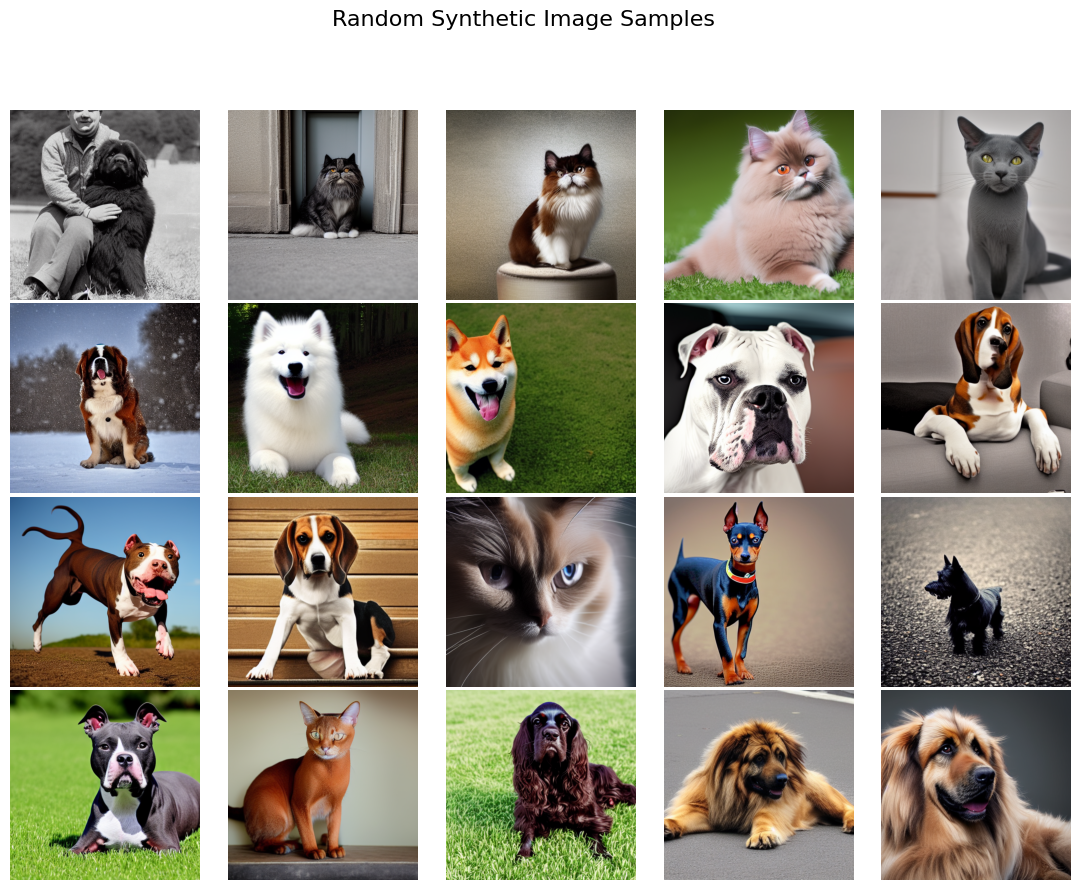

In [29]:
# display generated images
import os
import math
import matplotlib.pyplot as plt
from PIL import Image

# display images from showcase folder
SHOWCASE_DIR = os.path.join(DATA_DIR, "showcase_images")
image_files = sorted(os.listdir(SHOWCASE_DIR))

cols = 5
rows = 4

fig, axes = plt.subplots(rows, cols, figsize=(14, 10), dpi=100)

for ax, img_name in zip(axes.flatten(), image_files):
    img_path = os.path.join(SHOWCASE_DIR, img_name)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Random Synthetic Image Samples", fontsize=16)
plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

# Training and Evaluation

In this final stage, we evaluate whether synthetic data augmentation
improves classification performance.

Three training configurations are compared:

1. **Baseline**  
   - Real images only  
   - No data augmentation  
<br>

2. **Classical Augmentation**  
   - Real images  
   - Standard image transformations (flip, rotation, color jitter)
<br>
<br>

3. **Synthetic + Classical Augmentation**  
   - Real images with classical augmentation  
   - Additional synthetic images generated from selected captions  

Model:
- ResNet-18 pretrained on ImageNet

Evaluation:
- Accuracy on held-out test set
- Full classification report

This comparison quantifies the impact of generative data augmentation.

In [30]:
# Import training and evaluation module (final classification stage)
# This module:
# - Builds datasets
# - Trains models
# - Evaluates performance
# - Saves results and model weights

import training_evaluation
importlib.reload(training_evaluation)
from training_evaluation import run_training

In [31]:
#execute Training Pipeline
# Estimated runtime: ~1 minute on A100 GPU in colab
if RUN_TRAINING:

    results = run_training(
        PROJECT_ROOT, epochs=5, batch_size=64
    )


===== Training Baseline =====


100%|██████████| 18/18 [00:02<00:00,  8.40it/s]


Epoch 1/5, Loss: 3.0997


100%|██████████| 18/18 [00:02<00:00,  8.05it/s]


Epoch 2/5, Loss: 1.4395


...

Epoch 3/5, Loss: 0.8054


100%|██████████| 24/24 [00:05<00:00,  4.31it/s]


Epoch 4/5, Loss: 0.5201


100%|██████████| 24/24 [00:05<00:00,  4.22it/s]

Epoch 5/5, Loss: 0.3456


# Results

In [32]:
#print final accuracy comparison
print("Baseline Accuracy:", round(results["baseline"]["accuracy"],3))
print("Classical Augmentation Accuracy:", round(results["classical_only"]["accuracy"],3))
print("Synthetic + Classical Augmentation Accuracy:", round(results["synthetic_plus_classical"]["accuracy"],3))

Baseline Accuracy: 0.825
Classical Augmentation Accuracy: 0.828
Synthetic + Classical Augmentation Accuracy: 0.843


## Performance Comparison

In [33]:
import pandas as pd

# Build RESULTS comparison table

table_data = []

for setup_name in ["baseline", "classical_only", "synthetic_plus_classical"]:

    acc = results[setup_name]["accuracy"]
    report = results[setup_name]["report"]

    macro_f1 = report["macro avg"]["f1-score"]
    weighted_f1 = report["weighted avg"]["f1-score"]
    precision = report["macro avg"]["precision"]
    recall = report["macro avg"]["recall"]

    table_data.append({
        "Setup": setup_name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "Macro Precision": round(precision, 4),
        "Macro Recall": round(recall, 4)
    })

results_table = pd.DataFrame(table_data)

print("\n==============================")
print(" Final Evaluation Comparison ")
print("==============================")
print(results_table)

# save table to CSV
results_table.to_csv(
    os.path.join(PROJECT_ROOT, "models", "evaluation_summary_table.csv"),
    index=False
)


 Final Evaluation Comparison 
                      Setup  Accuracy  Macro F1  Weighted F1  Macro Precision  \
0                  baseline    0.8250    0.8228       0.8234           0.8275   
1            classical_only    0.8277    0.8242       0.8247           0.8335   
2  synthetic_plus_classical    0.8430    0.8410       0.8416           0.8477   

   Macro Recall  
0        0.8245  
1        0.8273  
2        0.8425  


## Class-Level Performance Comparison (F1-Score)

In [34]:

# CLASS LEVEL COMPARISON - F1 SCORE

import pandas as pd

class_names = results["class_names"]

class_level_rows = []

for class_name in class_names:

    row = {"Class": class_name}
    label_index = str(class_names.index(class_name))

    for setup in ["baseline", "classical_only", "synthetic_plus_classical"]:
        row[setup + "_F1"] = round(
            results[setup]["report"][label_index]["f1-score"], 4
        )

    class_level_rows.append(row)

class_level_df = pd.DataFrame(class_level_rows)

print("\n==============================")
print(" Per-Class F1 Comparison ")
print("==============================")
print(class_level_df)

# Save it
class_level_df.to_csv(
    os.path.join(PROJECT_ROOT, "models", "per_class_f1_comparison.csv"),
    index=False
)


 Per-Class F1 Comparison 
                         Class  baseline_F1  classical_only_F1  \
0                   Abyssinian       0.7283             0.7322   
1             American Bulldog       0.7542             0.7154   
2    American Pit Bull Terrier       0.5529             0.4690   
3                 Basset Hound       0.7723             0.8095   
4                       Beagle       0.7389             0.7961   
5                       Bengal       0.6844             0.7207   
6                       Birman       0.8098             0.7857   
7                       Bombay       0.8601             0.9011   
8                        Boxer       0.7714             0.8095   
9            British Shorthair       0.7400             0.7746   
10                   Chihuahua       0.6923             0.6932   
11                Egyptian Mau       0.8454             0.8612   
12      English Cocker Spaniel       0.8324             0.7614   
13              English Setter       0.8713      

## Confusion Matrix

In [35]:
class_names = results["class_names"]

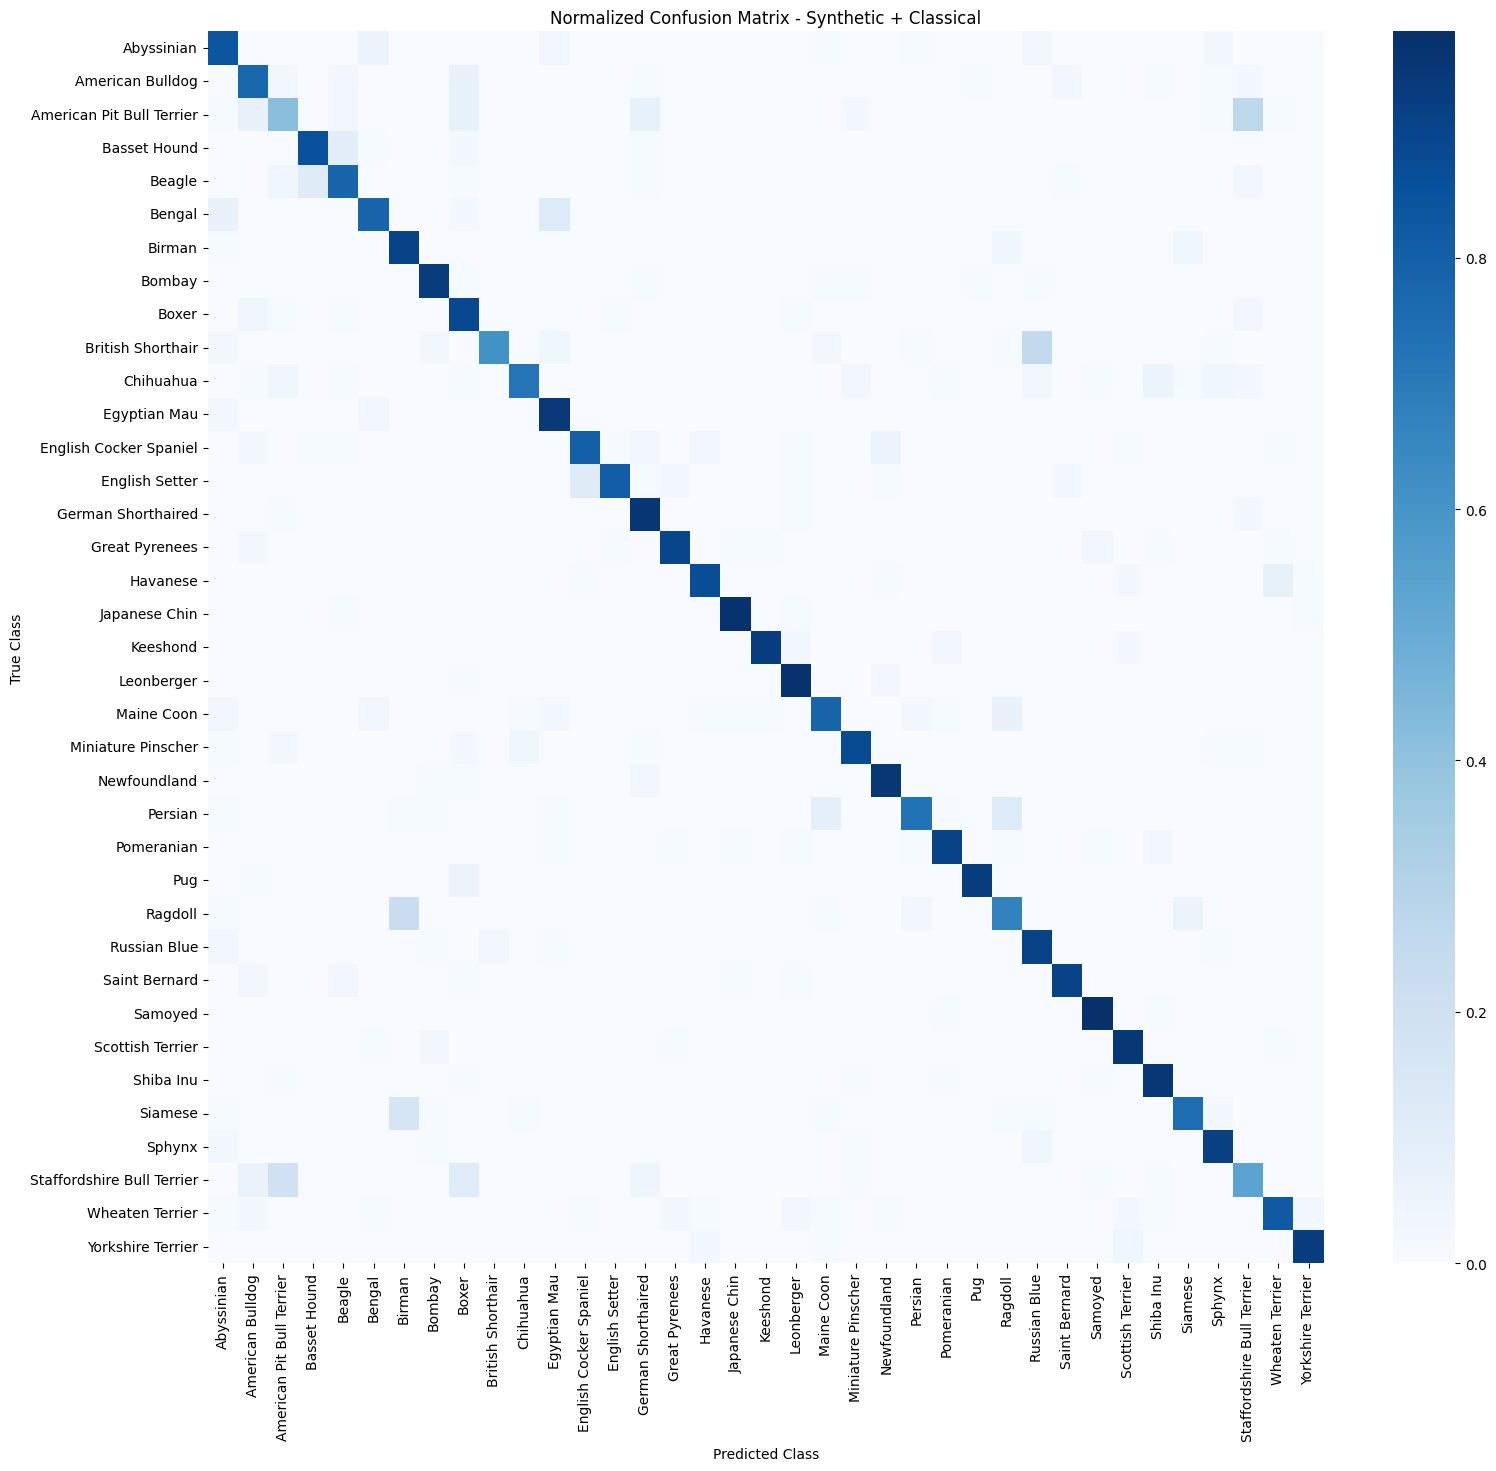

In [36]:
import seaborn as sns

cm = np.array(results["synthetic_plus_classical"]["confusion_matrix"])

cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title("Normalized Confusion Matrix - Synthetic + Classical")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [37]:
# Create output dir

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models/confusion_matrix_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

#Save PNG
png_path = os.path.join(OUTPUT_DIR, "confusion_matrix_normalized.png")
plt.figure(figsize=(18, 16))
plt.imshow(cm_normalized)
plt.colorbar()
plt.title("Normalized Confusion Matrix - Synthetic + Classical")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.savefig(png_path, bbox_inches="tight", dpi=300)
plt.close()

#Save CSV
csv_path = os.path.join(OUTPUT_DIR, "confusion_matrix_normalized.csv")
pd.DataFrame(cm_normalized, index=class_names, columns=class_names).to_csv(csv_path)

print("Saved files:")
print(png_path)
print(csv_path)

Saved files:
/content/Project_Generative_AI_for_Data_Augmentation/models/confusion_matrix_outputs/confusion_matrix_normalized.png
/content/Project_Generative_AI_for_Data_Augmentation/models/confusion_matrix_outputs/confusion_matrix_normalized.csv


# Conclusion

## **Project Overview**

This project evaluated whether text-driven synthetic data augmentation improves fine-grained image classification on the Oxford-IIIT Pet dataset (37 classes).

Three configurations were compared under identical conditions:

- Baseline – real images only

- Classical augmentation – standard transformations (flip, rotation, color jitter)

- Synthetic + classical augmentation – Stable Diffusion–generated images from filtered caption variations

## **Results**

**Accuracy**

- Baseline: 0.8250

- Classical augmentation: 0.8277

- Synthetic + classical: 0.8449

Key insights:

- Classical augmentation yielded only a marginal improvement over the baseline

- Synthetic + classical augmentation achieved +1.99 percentage points over baseline.

- This is a substantial gain for a 37-class fine-grained problem.

<br>

**Macro F1-Score**

Macro F1-score provides a more robust evaluation metric because it equally weights all classes, regardless of frequency.

- Baseline: 0.8228

- Classical augmentation: 0.8242

- Synthetic + classical: 0.8427

Key insights:

- ~+2.0 point improvement with synthetic data.

- Gains are distributed across classes, not concentrated in dominant ones.

- Weighted F1-score follows the same trend.

A visual inspection of the confusion matrix shows that the most frequent misclassifications occur between visually similar breeds:

- Ragdoll ↔ Birman

- Staffordshire Bull Terrier ↔ American Pit Bull Terrier

- Maine Coon ↔ Ragdoll

- Abyssinian ↔ Bengal.

<br>

**Class-Level Behaviour**

The synthetic + classical configuration improved several mid-performing and visually ambiguous breeds, including: Basset Hound, Bengal, Shiba Inu.

Some visually similar breed (e.g., American Pit Bull Terrier, Staffordshire Bull Terrier) remain challenging. These classes maintain lower F1-scores relative to the dataset average, even under synthetic augmentation.

<br>

## **Why the Improvement matters**

Although the synthetic + classical training configuration approx. tripled the dataset size (from 1104 to 3285 images), the performance gain is not just due to quantity. If the generated images were were noisy or unrealistic, performance would likely degrade.
Instead, the observed improvement suggests that the synthetic data adds:

- Structured semantic diversity

- New poses and compositions

- Varied backgrounds

This enhances feature learning and generalization.

<br>

## **Pipeline**

- caption generation (BLIP2)
- caption variation (instruction-tuned LLM – Mistral, selected after comparative evaluation)
- semantic filtering
- image synthesis (Stable Diffusion v1.5)
- training with pretrained ResNet-18 backbone

The experimental design controlled for model architecture, hyperparameters, dataset split, and random seed to isolate the effect of augmentation strategy.

Overall, the results demonstrate that a structured generative augmentation pipeline can produce meaningful improvements in classification performance in data-limited scenarios.


# Further Improvements

Future work could explore:

- larger synthetic-to-real data ratios
- different diffusion models
- execute full pipeline on the complete training set (thi study was conducted using 30% of the available training data due to computational constraints in Colab)

In [ ]:
# # capture exact libraries version used in current environemnt in colab
# !pip freeze | grep -E "torch|torchvision|sentence-transformers|transformers|diffusers|accelerate|sentencepiece|scikit-learn|xformers|matplotlib|numpy|pillow|tqdm|bitsandbytes" > requirements_locked.txt

-----------

<p align="center">
  <img src="https://github.com/Jorj91/Project_Generative_AI_for_Data_Augmentation/blob/dev/assets/synth_images_genai_project.png?raw=1" width="700"/>
</p>

In [ ]:
# import json

# NOTEBOOK_PATH = "/content/Project_Generative_AI_for_Data_Augmentation/main.ipynb"

# with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
#     nb = json.load(f)

# # Remove ANY widget metadata anywhere in the notebook
# for cell in nb.get("cells", []):
#     # Remove cell-level widgets metadata
#     if "metadata" in cell and "widgets" in cell["metadata"]:
#         del cell["metadata"]["widgets"]

#     # Remove widget metadata inside outputs
#     for output in cell.get("outputs", []):
#         if "metadata" in output and "widgets" in output["metadata"]:
#             del output["metadata"]["widgets"]

# # Also remove top-level widget blocks if any hidden keys exist
# if "metadata" in nb:
#     for key in list(nb["metadata"].keys()):
#         if "widget" in key.lower():
#             del nb["metadata"][key]

# with open(NOTEBOOK_PATH, "w", encoding="utf-8") as f:
#     json.dump(nb, f, indent=1)

# print("All widget metadata removed everywhere.")

In [ ]:
# import nbformat

# INPUT_PATH = "main.ipynb"
# OUTPUT_PATH = "main_rebuilt.ipynb"

# nb = nbformat.read(INPUT_PATH, as_version=4)

# new_nb = nbformat.v4.new_notebook()
# new_nb.metadata = nb.metadata  # keep clean metadata

# for cell in nb.cells:
#     # Preserve cell type (code or markdown)
#     if cell.cell_type == "code":
#         new_cell = nbformat.v4.new_code_cell(cell.source)
#     else:
#         new_cell = nbformat.v4.new_markdown_cell(cell.source)

#     # Preserve execution count
#     new_cell.execution_count = cell.get("execution_count", None)

#     # Clean outputs
#     cleaned_outputs = []
#     for output in cell.get("outputs", []):
#         if "data" in output:
#             output["data"] = {
#                 k: v for k, v in output["data"].items()
#                 if "widget" not in k.lower()
#             }
#         if "metadata" in output:
#             output["metadata"] = {
#                 k: v for k, v in output["metadata"].items()
#                 if "widget" not in k.lower()
#             }
#         cleaned_outputs.append(output)

#     new_cell.outputs = cleaned_outputs
#     new_nb.cells.append(new_cell)

# nbformat.write(new_nb, OUTPUT_PATH)

# print("Notebook successfully rebuilt as main_rebuilt.ipynb")